## Parte 1 - Preparación de datos

In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(random_state=42)
svm = SVC(probability=True, random_state=42)
lr = LogisticRegression(max_iter=500)

rf.fit(X_train, y_train)
svm.fit(X_train, y_train)
lr.fit(X_train, y_train)

print("RF:", accuracy_score(y_test, rf.predict(X_test)))
print("SVM:", accuracy_score(y_test, svm.predict(X_test)))
print("LR:", accuracy_score(y_test, lr.predict(X_test)))

RF: 0.9649122807017544
SVM: 0.9824561403508771
LR: 0.9736842105263158


In [3]:
from sklearn.ensemble import StackingClassifier

estimators = [
    ('rf', RandomForestClassifier(random_state=42)),
    ('svm', SVC(probability=True, random_state=42))
]

stack = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stack.fit(X_train, y_train)
print("STACKING:", accuracy_score(y_test, stack.predict(X_test)))

STACKING: 0.9649122807017544


--- MATRIZ DE CONFUSIÓN ---
[[40  3]
 [ 1 70]]

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



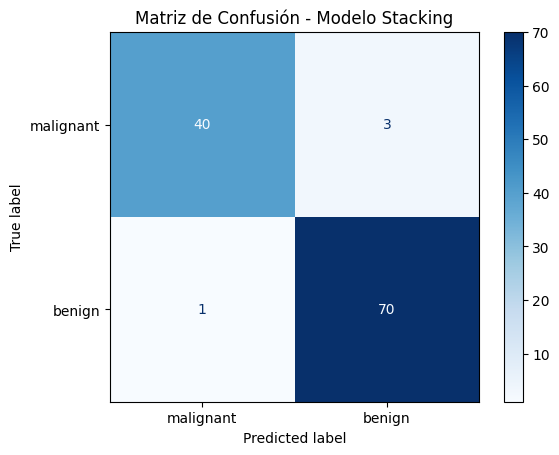

In [5]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = stack.predict(X_test)

# 1. Matriz de confusión en texto
print("--- MATRIZ DE CONFUSIÓN ---")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# 2. Informe de clasificación
print("\n--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# 3. Gráfica de la matriz de confusión
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión - Modelo Stacking")
plt.show()